In [ ]:
# Load libraries
from src import load_material as tools
from src import lambda_interpolate as interp
import numpy as np
import matplotlib.pyplot as plt
import miepython as mie
import pandas as pd

In [ ]:
# Load material data and preallocate arrays
material = "materials/silicon.csv"
ref_lam = []
ref_n = []
ref_k = []

In [ ]:
# Create daframes and double check sizes for correct calculations
df = pd.read_csv(material, delimiter = ",", header = 0, names = ["wl", "n", "k"], dtype = float)
ref_lam = df["wl"]
ref_n = df["n"]
ref_k = df["k"]

wvl_range = np.linspace(min(ref_lam), max(ref_lam), 1000)  # Wavelength range for interpolation in microns

print(len(ref_lam), len(ref_n), len(ref_k))

46 46 46


In [ ]:
# Interpolate
n, k = interp.wvl_interpolation(wvl_range, ref_lam, ref_n, ref_k)

In [ ]:
# Double check
print(k)

[7.26000000e-01 7.73649049e-01 8.21298098e-01 8.64956757e-01
 9.03942342e-01 9.42927928e-01 9.80099700e-01 1.01711632e+00
 1.05252920e+00 1.08534535e+00 1.11816149e+00 1.14940941e+00
 1.17753754e+00 1.20566567e+00 1.23379379e+00 1.26411411e+00
 1.29505506e+00 1.32599600e+00 1.35662162e+00 1.38615616e+00
 1.41569069e+00 1.44522523e+00 1.47458347e+00 1.50302414e+00
 1.53146480e+00 1.55990546e+00 1.58834612e+00 1.61627027e+00
 1.64383584e+00 1.67140140e+00 1.69896697e+00 1.72653253e+00
 1.75258759e+00 1.77719970e+00 1.80181181e+00 1.82642392e+00
 1.85103604e+00 1.87564815e+00 1.90055341e+00 1.92586873e+00
 1.95118404e+00 1.97649936e+00 2.00181467e+00 2.02712999e+00
 2.05244530e+00 2.07792230e+00 2.10376502e+00 2.12960773e+00
 2.15545045e+00 2.18129317e+00 2.20713589e+00 2.23297860e+00
 2.25882132e+00 2.28454065e+00 2.30969970e+00 2.33485875e+00
 2.36001780e+00 2.38517684e+00 2.41033589e+00 2.43549494e+00
 2.46065399e+00 2.48581304e+00 2.51082691e+00 2.53222875e+00
 2.55363059e+00 2.575032

In [25]:
# Cross section using interpolation
radius = 0.2  # in microns
m_i = n - 1.0j * k
x_i = 2 * np.pi * radius / wvl_range
cross_section_area = np.pi * radius**2
mu_i = 4 * np.pi * k / wvl_range  # nm
qext_i, qsca_i, qback_i, g_i = mie.efficiencies_mx(m_i, x_i)
sca_cross_section_i = qsca_i * cross_section_area
abs_cross_section_i = (qext_i - qsca_i) * cross_section_area

len(wvl_range), len(mu_i), len(sca_cross_section_i), len(abs_cross_section_i), len(k)


(1000, 1000, 1000, 1000, 1000)

In [ ]:
# TEST Cross section using reference data -- checking it has the right length -- WORKING CORRECTLY
m = ref_n - 1.0j * ref_k
x = 2 * np.pi * radius / ref_lam
cross_section_area = np.pi * radius**2
mu_a = 4 * np.pi * ref_k / ref_lam  # nm
qext, qsca, qback, g = mie.efficiencies_mx(m, x)

sca_cross_section = qsca * cross_section_area
abs_cross_section = (qext - qsca) * cross_section_area

len(ref_lam), len(mu_a), len(sca_cross_section), len(abs_cross_section), len(ref_k)

(46, 46, 46, 46, 46)

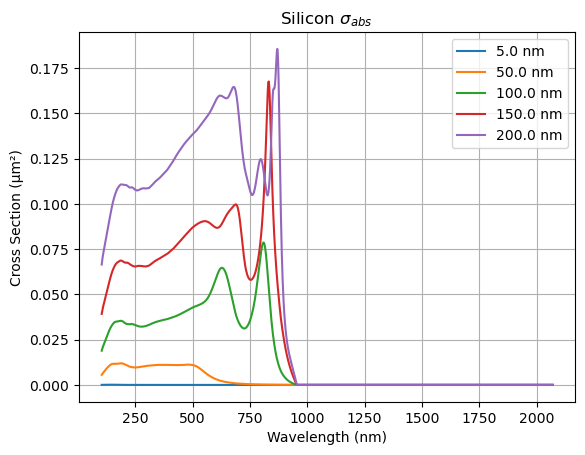

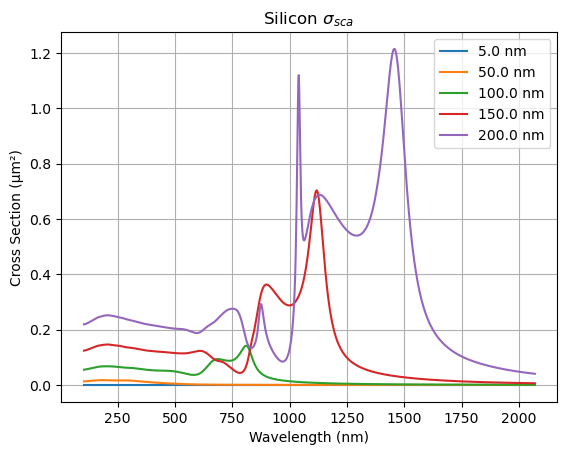

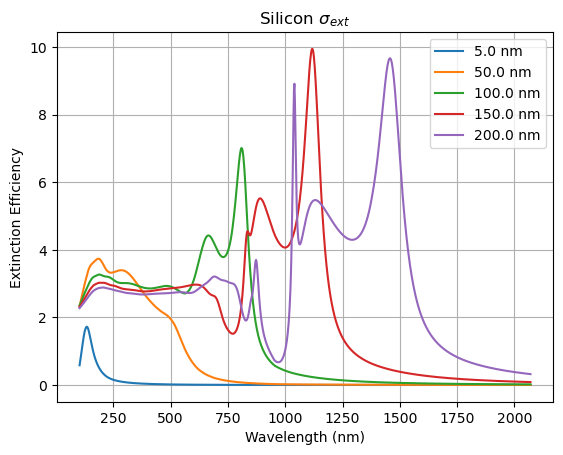

In [ ]:
# TEST cross section for different radii in Silicon -- William's collaboration -- RUNS CORRECTLY
r_range = [0.005, 0.05, 0.1, 0.15,  0.2]  # in microns
m = n - 1.0j * k

for i in r_range:
    x = 2 * np.pi * i / wvl_range
    cross_section_area = np.pi * i**2
    mu = 4 * np.pi * k / wvl_range  # nm
    qext, qsca, qback, g = mie.efficiencies_mx(m, x)
    sca_cross_section = qsca * cross_section_area
    abs_cross_section = (qext - qsca) * cross_section_area

    plt.figure(1)
    plt.plot(wvl_range*1000, abs_cross_section, label=f"{i*1000} nm")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Cross Section (μm²)")
    plt.title(r'Silicon $\sigma_{abs}$ ')
    plt.legend()
    plt.grid()

    plt.figure(2)
    plt.plot(wvl_range*1000, sca_cross_section, label=f"{i*1000} nm")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Cross Section (μm²)")
    plt.title(r'Silicon $\sigma_{sca}$ ')
    plt.legend()
    plt.grid()

    plt.figure(3)
    plt.plot(wvl_range*1000, qext, label=f"{i*1000} nm")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Extinction Efficiency")
    plt.title(r'Silicon $\sigma_{ext}$ ')
    plt.legend()
    plt.grid()

plt.show()


Text(0, 0.5, 'Cross Section (µm²)')

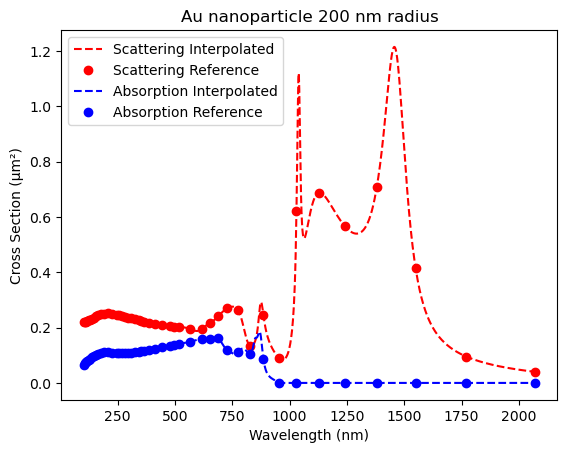

In [ ]:
# TEST check interpolation vs raw estimations -- WORKING PROPERLY
plt.plot(wvl_range * 1000, sca_cross_section_i, "--r")
plt.plot(ref_lam * 1000, sca_cross_section, "or")
plt.plot(wvl_range * 1000, abs_cross_section_i, "--b")
plt.plot(ref_lam * 1000, abs_cross_section, "ob")
plt.legend(["Scattering Interpolated", "Scattering Reference", "Absorption Interpolated", "Absorption Reference"])
plt.title(f"Au nanoparticle {radius*1000:.0f} nm radius")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Cross Section (µm²)")